# Extra factor: linearised Gaussian vs $\chi^2$

For a **parallax-selected** sample, the linearised Gaussian per-star likelihood carries an extra factor relative to the $\chi^2$ kernel:
$$
   f_i = \left(\frac{\varpi_{\min} + \delta\varpi}{\varpi_{\rm phot,}\!_i}\right)^{\!3}
   \frac{1}{\sqrt{\left(\frac{\ln 10}{5}\right)^2 \varpi_{\rm phot,}\!_i^{\,2}\, \sigma_{1,i}^2 + \sigma_{\varpi,i}^2}}
$$

We evaluate this numerically for C27-like parameters ($\varpi_{\min} = 0.8$ mas).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

%matplotlib inline

In [6]:
# Fiducial values (C27-like)
varpi_min = 0.8          # mas, parallax selection cut
delta_pi = -0.014        # mas, parallax zero-point offset
sigma_int = 0.06         # mag, intrinsic PL scatter
sigma_m_obs = 0.028      # mag, photometric uncertainty
sigma_varpi = 0.019      # mas, parallax uncertainty

sigma_1 = np.sqrt(sigma_m_obs**2 + sigma_int**2)
print(f"sigma_1 = {sigma_1:.4f} mag")

sigma_1 = 0.0662 mag


In [7]:
varpi_phot = np.linspace(0.5, 5.0, 500)  # mas

def extra_factor(varpi_phot, delta_pi, varpi_min, sigma_1, sigma_varpi):
    ratio = (varpi_min + delta_pi) / varpi_phot
    sigma_tilde = np.sqrt(
        (np.log(10) / 5)**2 * varpi_phot**2 * sigma_1**2 + sigma_varpi**2)
    return ratio**3 / sigma_tilde

def log_extra_factor(varpi_phot, delta_pi, varpi_min, sigma_1, sigma_varpi):
    log_sel = 3 * np.log(varpi_min + delta_pi) - 3 * np.log(varpi_phot)
    sigma_tilde2 = (np.log(10) / 5)**2 * varpi_phot**2 * sigma_1**2 + sigma_varpi**2
    return log_sel - 0.5 * np.log(sigma_tilde2)

### Parallax-selected: why does $\chi^2$ converge to the linearised Gaussian?

The linearised Gaussian log-likelihood is $\ln\mathcal{L} = -\frac{1}{2}\chi^2 + \sum_i \ln f_i$. For the two to give the same posterior, $\sum_i \ln f_i$ must be approximately flat over the region where $\chi^2$ localises the parameters. We check this on a mock C27 sample.

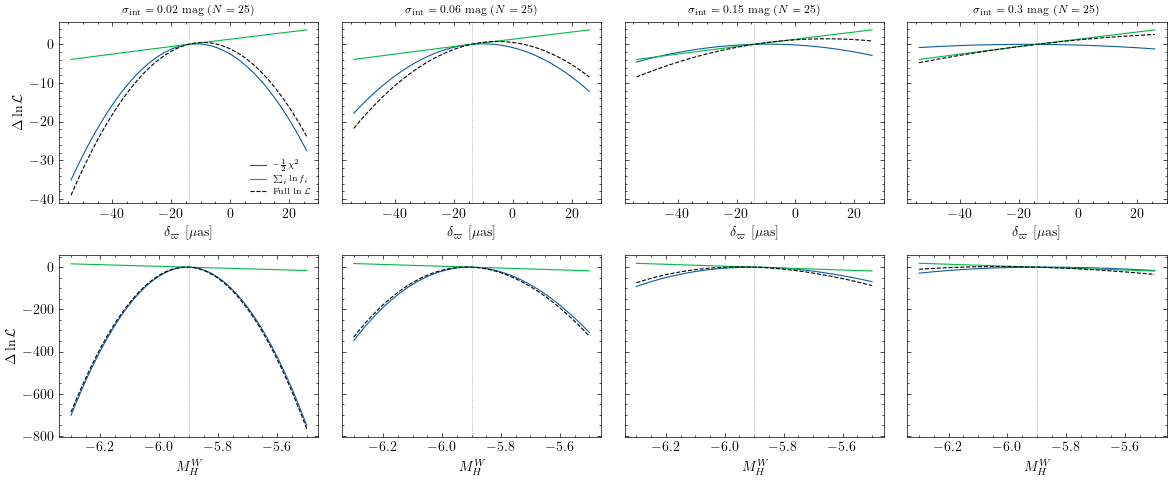

In [8]:
import sys
from pathlib import Path

MOCK_RUN_DIR = None
for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    candidate = parent / "scripts" / "runs" / "mwcepheids" / "mocks"
    if candidate.exists():
        MOCK_RUN_DIR = candidate
        break
if MOCK_RUN_DIR is None:
    raise FileNotFoundError("Could not find scripts/runs/mwcepheids/mocks")
if str(MOCK_RUN_DIR) not in sys.path:
    sys.path.insert(0, str(MOCK_RUN_DIR))

from mock_utils import (
    generate_mock, DEFAULT_CONFIGS,
    MWH_true, bW_true, ZW_true, delta_pi_true,
    sigma_m_obs as mock_sigma_m, sigma_varpi_obs as mock_sigma_varpi,
)
import copy


def scan_loglike_consistent(sint, seed=42, which_param="delta_pi"):
    """Generate a mock with given sigma_int and scan chi2 vs extra term."""
    CONFIGS = copy.deepcopy(DEFAULT_CONFIGS)
    rng = np.random.default_rng(seed)
    cfg = CONFIGS["C27"]
    N = cfg["N_parent"]
    e = cfg["dist_k"] + 1
    u = rng.uniform(0, 1, N)
    d_true = (cfg["d_min"]**e + u * (cfg["d_max"]**e - cfg["d_min"]**e)
              )**(1 / e)
    logP = rng.normal(cfg["mu_logP"], cfg["sigma_logP"], N)
    OH = rng.normal(cfg["mu_OH"], cfg["sigma_OH"], N)

    M = MWH_true + bW_true * (logP - 1) + ZW_true * OH
    mu = 5 * np.log10(d_true) + 10
    m = M + mu + rng.normal(0, sint, N)

    sm = np.full(N, mock_sigma_m)
    sv = np.full(N, mock_sigma_varpi)
    m_obs = m + rng.normal(0, mock_sigma_m, N)
    varpi_obs = 1.0 / d_true - delta_pi_true + rng.normal(0, mock_sigma_varpi, N)

    from scipy.stats import norm as sp_norm
    prob = sp_norm.cdf(
        (varpi_obs - cfg["varpi_cut"]) / cfg["varpi_width"])
    sel = rng.uniform(size=N) < prob

    if sel.sum() < 5:
        return None

    m_s = m_obs[sel]
    lP_s = logP[sel]
    oh_s = OH[sel]
    vo_s = varpi_obs[sel]
    sm_s = sm[sel]
    sv_s = sv[sel]

    if which_param == "delta_pi":
        scan = np.linspace(delta_pi_true - 0.04, delta_pi_true + 0.04, 300)
    else:
        scan = np.linspace(MWH_true - 0.4, MWH_true + 0.4, 300)

    chi2_vals, extra_vals = [], []
    for v in scan:
        MWH = v if which_param == "MWH" else MWH_true
        dpi = v if which_param == "delta_pi" else delta_pi_true

        M_pred = MWH + bW_true * (lP_s - 1) + ZW_true * oh_s
        vp = 10**(-0.2 * (m_s - M_pred - 10))
        s1 = np.sqrt(sm_s**2 + sint**2)
        st2 = (np.log(10) / 5)**2 * vp**2 * s1**2 + sv_s**2

        chi2_vals.append(-0.5 * np.sum((vo_s - vp + dpi)**2 / st2))
        extra_vals.append(np.sum(
            3 * np.log(varpi_min + dpi) - 3 * np.log(vp)
            - 0.5 * np.log(st2)))

    chi2_vals = np.array(chi2_vals)
    extra_vals = np.array(extra_vals)
    full_vals = chi2_vals + extra_vals

    # Find index closest to true value
    if which_param == "delta_pi":
        i_true = np.argmin(np.abs(scan - delta_pi_true))
    else:
        i_true = np.argmin(np.abs(scan - MWH_true))

    # Normalise all relative to value at true parameters
    chi2_vals -= chi2_vals[i_true]
    extra_vals -= extra_vals[i_true]
    full_vals -= full_vals[i_true]

    return scan, chi2_vals, extra_vals, full_vals, sel.sum()


sint_vals = [0.02, 0.06, 0.15, 0.3]

with plt.style.context("science"):
    fig, axes = plt.subplots(2, len(sint_vals),
                             figsize=(3 * len(sint_vals), 5),
                             sharey="row")

    for j, si in enumerate(sint_vals):
        for i, param in enumerate(["delta_pi", "MWH"]):
            ax = axes[i, j]
            result = scan_loglike_consistent(si, which_param=param)
            if result is None:
                ax.text(0.5, 0.5, "Too few stars", transform=ax.transAxes,
                        ha="center")
                continue
            scan, c, e, full, nsel = result

            xvals = scan * 1e3 if param == "delta_pi" else scan
            true = delta_pi_true * 1e3 if param == "delta_pi" else MWH_true

            ax.plot(xvals, c, lw=0.8, label=r"$-\frac{1}{2}\chi^2$")
            ax.plot(xvals, e, lw=0.8, label=r"$\sum_i \ln f_i$")
            ax.plot(xvals, full, "k--", lw=0.8,
                    label=r"Full $\ln\mathcal{L}$")
            ax.axvline(true, ls=":", color="grey", lw=0.5)

            if param == "delta_pi":
                ax.set_xlabel(r"$\delta_\varpi$ [$\mu$as]")
            else:
                ax.set_xlabel(r"$M^W_H$")

            if i == 0:
                ax.set_title(
                    rf"$\sigma_{{\rm int}} = {si}$ mag ($N = {nsel}$)",
                    fontsize=8)
            if j == 0:
                ax.set_ylabel(r"$\Delta \ln \mathcal{L}$")
            if i == 0 and j == 0:
                ax.legend(fontsize=6)

    fig.tight_layout()
    plt.show()

### Dependence of the extra factor on $\sigma_{\rm int}$

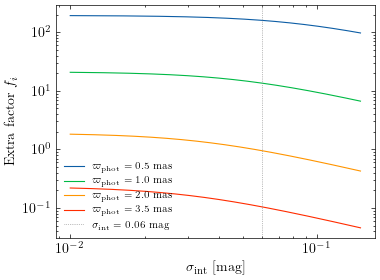

In [9]:
sint_grid = np.linspace(0.01, 0.15, 500)
vp_vals = [0.5, 1.0, 2.0, 3.5]

with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(4, 3))
    for vp in vp_vals:
        s1 = np.sqrt(sigma_m_obs**2 + sint_grid**2)
        f = extra_factor(vp, delta_pi, varpi_min, s1, sigma_varpi)
        ax.plot(sint_grid, f, lw=0.8,
                label=rf"$\varpi_{{\rm phot}} = {vp}$ mas")
    ax.axvline(sigma_int, ls=":", color="grey", lw=0.5,
               label=rf"$\sigma_{{\rm int}} = {sigma_int}$ mag")
    ax.set_xlabel(r"$\sigma_{\rm int}$ [mag]")
    ax.set_ylabel(r"Extra factor $f_i$")
    ax.legend(fontsize=7)
    ax.set_yscale("log")
    ax.set_xscale("log")
    fig.tight_layout()
    plt.show()

### Magnitude-selected case

The extra factor is:
$$
g_i = \frac{1}{\tilde\sigma_i} = \frac{1}{\sqrt{\left(\frac{\ln 10}{5}\right)^2 \varpi_{\rm phot}^2\, \sigma_1^2 + \sigma_\varpi^2}}
$$

The only model-parameter dependence enters through $\varpi_{\rm phot}(M^W_H, b_W, Z_W)$. The quantities $\sigma_1$ and $\sigma_\varpi$ are fixed per star.

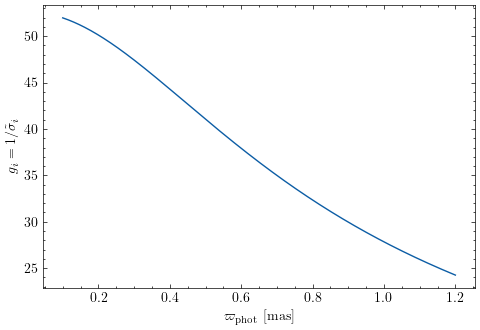

In [10]:
vp_grid_m = np.linspace(0.1, 1.2, 500)

g = 1.0 / np.sqrt(
    (np.log(10) / 5)**2 * vp_grid_m**2 * sigma_1**2 + sigma_varpi**2)

with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.plot(vp_grid_m, g)
    ax.set_xlabel(r"$\varpi_{\rm phot}$ [mas]")
    ax.set_ylabel(r"$g_i = 1/\tilde{\sigma}_i$")
    fig.tight_layout()
    plt.show()

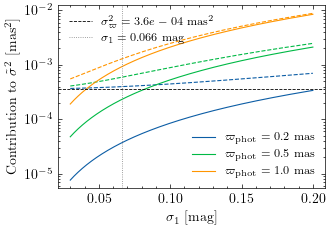

In [11]:
s1_grid = np.linspace(0.03, 0.20, 500)
vp_vals = [0.2, 0.5, 1.0]

with plt.style.context("science"):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    curves = []
    for vp in vp_vals:
        term_m = (np.log(10) / 5)**2 * vp**2 * s1_grid**2
        l, = ax.plot(s1_grid, term_m, lw=0.8,
                     label=rf"$\varpi_{{\rm phot}} = {vp}$ mas")
        curves.append(l)
        # Quadrature sum
        ax.plot(s1_grid, term_m + sigma_varpi**2, ls="--", lw=0.8,
                color=l.get_color())
    lh = ax.axhline(sigma_varpi**2, ls="--", color="k", lw=0.6,
                     label=rf"$\sigma_\varpi^2 = {sigma_varpi**2:.1e}$ mas$^2$")
    lv = ax.axvline(sigma_1, ls=":", color="grey", lw=0.6,
                     label=rf"$\sigma_1 = {sigma_1:.3f}$ mag")

    leg1 = ax.legend(handles=[lh, lv], loc="upper left", fontsize="small")
    ax.add_artist(leg1)
    ax.legend(handles=curves, loc="lower right", fontsize="small")

    ax.set_xlabel(r"$\sigma_1$ [mag]")
    ax.set_ylabel(r"Contribution to $\tilde{\sigma}^2$ [mas$^2$]")
    ax.set_yscale("log")
    fig.tight_layout()
    plt.show()